<div style="
    background: #111827;
    color: white;
    padding: 35px;
    border-radius: 12px;
    margin-bottom: 25px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.15);
    font-family: Arial, sans-serif;
">

   <h1 style="
        margin: 0;
        font-size: 2.5rem;
        text-align: center;
        text-transform:uppercase;
   ">
        análise rfm para segmentação de clientes
   </h1>

   <hr style="
        border: none;
        height: 1px;
        background: rgba(255,255,255,0.2);
        margin: 25px 0 10px 0;
   ">
   <div style="
        display: flex;
        flex-direction:column;
        justify-content:center;
        align-items: center;
        flex-wrap: wrap;
        gap: 15px;
        font-size: .9rem;
        color: #94a3b8;
   ">
       <p style="font-weight: 500; font-size:1.2rem; line-height: 1.5; letter-spacing:2px; margin-bottom:-.5rem;">
            Autor: <strong style="color: white; font-weight: 600;">Wellington M. Santos</strong>
       </p>
       <div style="display: flex; gap: 30px; font-weight: 500; justify-content:center">
            <a href="https://www.linkedin.com/in/wellington-moreira-santos"
               target="_blank"
               style="color:#93c5fd; text-decoration:none;">
               LinkedIn
            </a>
            <a href="mailto:wsantos08@hotmail.com"
               style="color:#93c5fd; text-decoration:none;">
               Contato
            </a>
            <a href="https://github.com/esscova"
               target="_blank"
               style="color:#93c5fd; text-decoration:none;">
               GitHub
            </a>
       </div>
   </div>

</div>

Neste projeto, eu aplico análise RFM (Recency, Frequency, Monetary) para segmentar a base de clientes do dataset Online Retail II, identificando grupos com diferentes perfis de comportamento de compra. RFM é uma técnica de mineração de dados que rankeia clientes por três dimensões observadas diretamente no histórico de transações, sem treinamento de modelo ou generalização para novos dados, apenas descoberta de padrões a partir de regras de quartis.

Escolho o Online Retail II por ser o mesmo dataset utilizado no projeto de Market Basket Analysis deste repositório, o que permite explorar duas técnicas distintas de mineração de dados, regras de associação e segmentação comportamental, sobre uma mesma base transacional real de varejo. A análise é construída de forma independente, com inspeção e tratamento próprios, sem reaproveitar decisões do projeto anterior.

As principais ferramentas utilizadas são `pandas` para manipulação dos dados, `matplotlib` e `seaborn` para visualização, e funções nativas do pandas como `qcut` para discretização em quartis.

O notebook está organizado nas seguintes seções:

1. Imports e Configurações
2. Coleta e Inspeção dos Dados
3. Análise Exploratória
4. Visualizações
5. Conclusão e Considerações Finais
6. Referências

---

## 1. Imports e Configurações

Utilizo `pandas` para carregamento e manipulação do dataset, `matplotlib` e `seaborn` para construção dos gráficos, e o módulo `datetime` para o cálculo de recência a partir das datas de transação.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import warnings
import session_info

warnings.filterwarnings('ignore')
session_info.show(dependencies=False)

In [3]:
plt.rcParams.update({
    'figure.facecolor': '#0f172a',
    'axes.facecolor':   '#1e293b',
    'axes.edgecolor':   '#334155',
    'axes.labelcolor':  '#94a3b8',
    'xtick.color':      '#94a3b8',
    'ytick.color':      '#94a3b8',
    'text.color':       '#f1f5f9',
    'grid.color':       '#334155',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
})

---

## 2. Coleta e Inspeção dos Dados

### 2.1 Carregamento do dataset

Carrego o Online Retail II diretamente do arquivo original, contendo transações de varejo online entre 2009 e 2011.

In [13]:
try:
    df = pd.read_excel('online_retail_II.xlsx')
    display(df.head())
except FileNotFoundError: print('Arquivo não encontrado, verifique o caminho.')
except Exception as e: print(f'Erro: {str(e)}')

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


O dataset reúne registros de transações individuais, com identificação de cliente, produto, quantidade, preço unitário e data da compra.

### 2.2 Visão geral da estrutura

Verifico o volume de registros, os tipos de dados e a presença de colunas relevantes para o cálculo RFM.

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 32.1+ MB


A coluna de identificação do cliente (`Customer ID`) é essencial para o agrupamento, e a coluna de data (`InvoiceDate`) é necessária para o cálculo de recência. Confirmo os tipos antes de prosseguir.

### 2.3 Valores nulos

In [9]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

Clientes sem `Customer ID` não podem ser segmentados individualmente, então são candidatos a remoção na etapa de tratamento.

### 2.4 Estatísticas descritivas

In [10]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845018,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


Observo a presença de valores de quantidade e preço fora do esperado, o que investigo na análise exploratória antes de decidir sobre remoção.

---

## 3. Análise Exploratória

### 3.1 Remoção de registros sem identificação de cliente

In [14]:
antes = len(df)
df = df[df['Customer ID'].notnull()]

print(f"Registros removidos por ausência de Customer ID : {antes - len(df)}")
print(f"Registros restantes                             : {len(df)}")

Registros removidos por ausência de Customer ID : 107927
Registros restantes                             : 417534


### 3.2 Tratamento de quantidades e preços inválidos

Quantidades negativas geralmente representam devoluções, e preços iguais a zero não correspondem a transações de venda efetivas. Removo ambos os casos, já que o objetivo é medir comportamento de compra.

In [15]:
antes = len(df)
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

print(f"Registros removidos por quantidade ou preço inválidos : {antes - len(df)}")
print(f"Registros restantes                                   : {len(df)}")

Registros removidos por quantidade ou preço inválidos : 9870
Registros restantes                                   : 407664


### 3.3 Distribuição geográfica

Antes de decidir o escopo geográfico da análise, verifico como os clientes estão distribuídos entre os países.

In [16]:
df['Country'].value_counts().head(10)

Country
United Kingdom    370929
EIRE                8507
Germany             7654
France              5470
Netherlands         2729
Spain               1235
Switzerland         1170
Belgium             1037
Portugal             984
Sweden               868
Name: count, dtype: int64

> O Reino Unido concentra 370.929 dos 407.664 registros válidos, o equivalente a aproximadamente 91% do total. O segundo país mais representado, Irlanda (EIRE), não chega a 2,1% dos registros. Essa concentração torna o dataset essencialmente um retrato do varejo britânico, e manter os demais países na análise introduziria clientes com histórico raso e comportamento de nicho que distorceria os quartis. Opto por não aplicar filtro geográfico explícito: a dominância do Reino Unido já é suficiente para que os quartis reflitam majoritariamente esse mercado, e remover os demais países eliminaria clientes legítimos sem ganho analítico relevante.

### 3.4 Criação da coluna de valor total por transação

In [17]:
df['TotalPrice'] = df['Quantity'] * df['Price']
df.sample(3)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
95245,498379,84997C,BLUE 3 PIECE MINI DOTS CUTLERY SET,7,2010-02-18 14:29:00,3.75,13680.0,United Kingdom,26.25
245657,513188,21541,DINOSAURS WATER TRANSFER TATTOOS,12,2010-06-22 14:00:00,0.85,12724.0,France,10.20
386767,526631,21080,SET/20 RED RETROSPOT PAPER NAPKINS,24,2010-10-12 13:03:00,0.85,15738.0,United Kingdom,20.40


### 3.5 Cálculo das métricas RFM

Defino uma data de referência posterior à última transação do dataset, e calculo recência, frequência e valor monetário por cliente.

In [18]:
data_referencia = df['InvoiceDate'].max() + dt.timedelta(days=1)
data_referencia

Timestamp('2010-12-10 20:01:00')

In [19]:
rfm = df.groupby('Customer ID').agg(
    recencia=('InvoiceDate', lambda x: (data_referencia - x.max()).days),
    frequencia=('Invoice', 'nunique'),
    monetario=('TotalPrice', 'sum')
)
rfm

,recencia,frequencia,monetario
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93
...,...,...,...
18283.0,18,6,641.77
18284.0,67,1,461.68
18285.0,296,1,427.00


### 3.6 Inspeção da distribuição RFM

In [20]:
rfm.describe()

,recencia,frequencia,monetario
count,4312.000000,4312.000000,4312.000000
mean,91.171846,4.455705,2048.238236
std,96.860633,8.170213,8914.481280
min,1.000000,1.000000,2.950000
25%,18.000000,1.000000,307.987500
50%,53.000000,2.000000,706.020000
75%,136.000000,5.000000,1723.142500
max,374.000000,205.000000,349164.350000


> As três métricas apresentam distribuição fortemente assimétrica à direita. A recência média é de 91 dias, porém a mediana é 53 dias, indicando que a maioria dos clientes comprou há menos de dois meses, mas uma cauda longa puxa a média para cima. A frequência tem mediana de apenas 2 pedidos, contra uma média de 4,5 e um máximo de 205, revelando que poucos clientes muito ativos distorcem a distribuição. O valor monetário tem comportamento ainda mais extremo: mediana de £706, média de £2.048 e máximo de £349.164. Nesse cenário, dividir por média e desvio padrão produziria fronteiras de grupo distorcidas pelos outliers. O uso de quartis é mais robusto porque as fronteiras são definidas por posição na distribuição, não por distância à média.

### 3.7 Cálculo dos quartis e pontuação RFM

In [21]:
rfm['r_quartil'] = pd.qcut(rfm['recencia'], 4, labels=[4, 3, 2, 1])
rfm['f_quartil'] = pd.qcut(rfm['frequencia'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['m_quartil'] = pd.qcut(rfm['monetario'], 4, labels=[1, 2, 3, 4])
rfm

,recencia,frequencia,monetario,r_quartil,f_quartil,m_quartil
Customer ID,,,,,,
12346.0,165,11,372.86,1,4,2
12347.0,3,2,1323.32,4,2,3
12348.0,74,1,222.16,2,1,1
12349.0,43,3,2671.14,3,3,4
12351.0,11,1,300.93,4,1,1
...,...,...,...,...,...,...
18283.0,18,6,641.77,4,4,2
18284.0,67,1,461.68,2,2,2
18285.0,296,1,427.00,1,2,2


In [22]:
rfm['RFM_Score'] = (
    rfm['r_quartil'].astype(str) +
    rfm['f_quartil'].astype(str) +
    rfm['m_quartil'].astype(str)
)
rfm

,recencia,frequencia,monetario,r_quartil,f_quartil,m_quartil,RFM_Score
Customer ID,,,,,,,
12346.0,165,11,372.86,1,4,2,142
12347.0,3,2,1323.32,4,2,3,423
12348.0,74,1,222.16,2,1,1,211
12349.0,43,3,2671.14,3,3,4,334
12351.0,11,1,300.93,4,1,1,411
...,...,...,...,...,...,...,...
18283.0,18,6,641.77,4,4,2,442
18284.0,67,1,461.68,2,2,2,222
18285.0,296,1,427.00,1,2,2,122


> O `rank(method='first')` foi suficiente para evitar bin edges duplicados em frequência. Recência e monetário não apresentaram o problema, e `qcut` foi aplicado diretamente nessas duas variáveis sem ajuste adicional.

### 3.8 Nomeação dos segmentos

Trago a pontuação RFM para rótulos de negócio interpretáveis, com regras explícitas sobre o que caracteriza cada grupo.

In [23]:
def classificar_segmento(row):
    r, f, m = int(row['r_quartil']), int(row['f_quartil']), int(row['m_quartil'])
    if r >= 4 and f >= 4 and m >= 4:
        return 'Campeões'
    elif r >= 3 and f >= 3:
        return 'Clientes fiéis'
    elif r >= 4 and f <= 2:
        return 'Novos clientes'
    elif r <= 2 and f >= 3:
        return 'Em risco'
    elif r <= 2 and f <= 2:
        return 'Hibernando'
    else:
        return 'Regular'

In [24]:
rfm['segmento'] = rfm.apply(classificar_segmento, axis=1)
rfm

,recencia,frequencia,monetario,r_quartil,f_quartil,m_quartil,RFM_Score,segmento
Customer ID,,,,,,,,
12346.0,165,11,372.86,1,4,2,142,Em risco
12347.0,3,2,1323.32,4,2,3,423,Novos clientes
12348.0,74,1,222.16,2,1,1,211,Hibernando
12349.0,43,3,2671.14,3,3,4,334,Clientes fiéis
12351.0,11,1,300.93,4,1,1,411,Novos clientes
...,...,...,...,...,...,...,...,...
18283.0,18,6,641.77,4,4,2,442,Clientes fiéis
18284.0,67,1,461.68,2,2,2,222,Hibernando
18285.0,296,1,427.00,1,2,2,122,Hibernando


> Os limiares foram definidos com base na lógica de negócio de cada dimensão RFM. Campeões exigem pontuação máxima nas três dimensões simultaneamente: compraram recentemente (r=4), com alta frequência (f=4) e alto valor (m=4). Clientes fiéis mantêm recência e frequência elevadas (r≥3, f≥3), independentemente do valor monetário, pois o que os define é o hábito de compra. Novos clientes têm recência alta (r=4) mas frequência baixa (f≤2), o que indica chegada recente sem histórico consolidado. Em risco agrupa clientes com frequência alta (f≥3) mas recência baixa (r≤2), isto é, compradores habituais que pararam de comprar. Hibernando reúne clientes com recência e frequência baixas (r≤2, f≤2), sem sinais recentes de engajamento. Regular captura os casos intermediários que não se encaixam em nenhum dos perfis anteriores.

### 3.9 Resumo da análise exploratória

O pipeline de limpeza removeu 107.927 registros sem identificação de cliente e 9.870 com quantidade ou preço inválidos, partindo de 525.461 registros brutos e chegando a 407.664 transações válidas. 

A análise manteve todos os países, dado que o Reino Unido representa 91% dos registros e o filtro geográfico não traria ganho analítico relevante. 

A partir dessas transações, foram identificados 4.312 clientes únicos e segmentados em seis grupos com perfis comportamentais distintos. 

O segmento mais numeroso é Hibernando, com cerca de 1.450 clientes, seguido de Clientes fiéis com cerca de 1.000. Novos clientes é o menor grupo, com aproximadamente 235 clientes.

---

## 4. Visualizações

### 4.1 Distribuição dos clientes por segmento

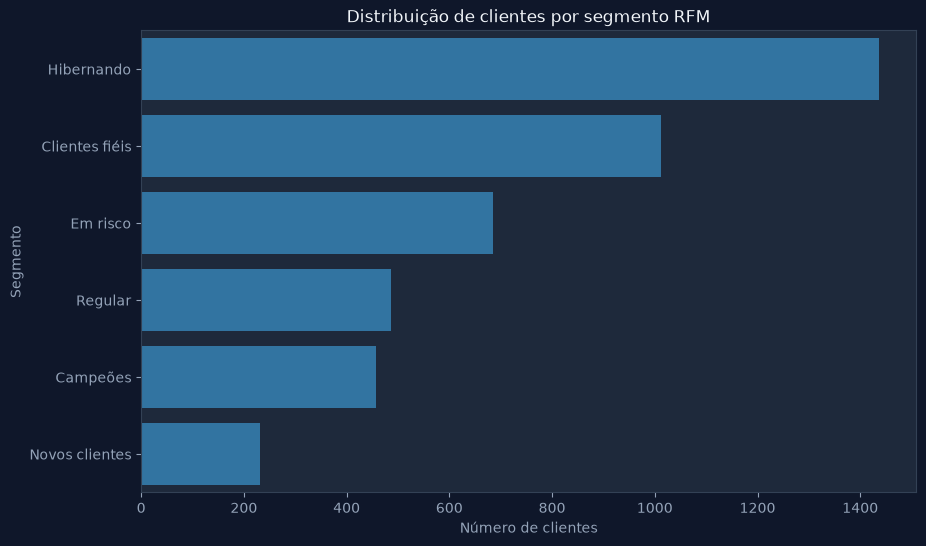

In [25]:
plt.figure(figsize=(10, 6))
sns.countplot(data=rfm, y='segmento', order=rfm['segmento'].value_counts().index)
plt.title('Distribuição de clientes por segmento RFM')
plt.xlabel('Número de clientes')
plt.ylabel('Segmento')
plt.show()

> Hibernando é o segmento dominante, concentrando cerca de um terço de toda a base. Isso indica que uma parcela significativa dos clientes do período teve apenas interações esparsas e não retornou. Clientes fiéis formam o segundo maior grupo, o que é positivo: representa uma base sólida de compradores recorrentes. Em risco e Regular têm volumes intermediários e merecem atenção: o primeiro agrupa ex-compradores frequentes que deixaram de comprar, e o segundo inclui clientes sem perfil definido que podem migrar para qualquer direção. Campeões e Novos clientes são os menores grupos, sendo que a escassez de Campeões é esperada em qualquer base real, dada a exigência simultânea de alta recência, frequência e valor.

### 4.2 Valor monetário médio por segmento

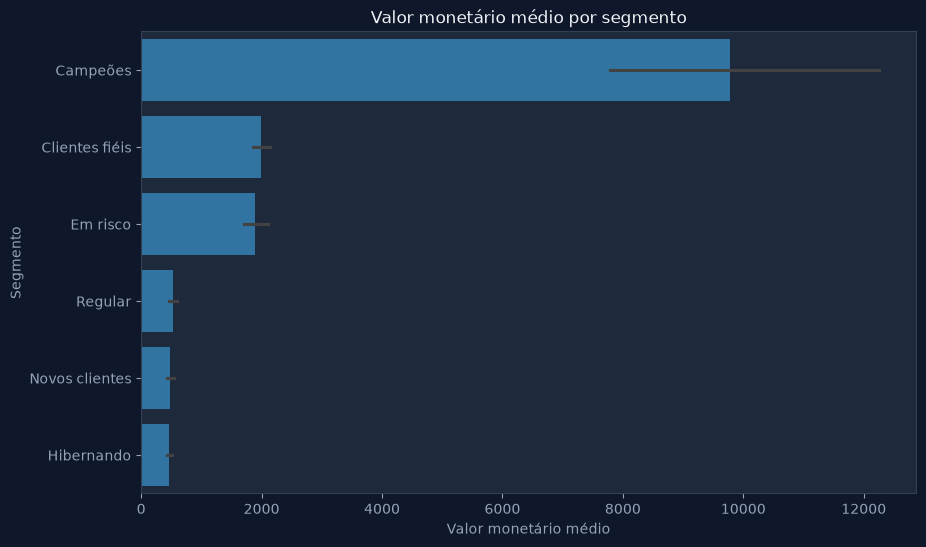

In [26]:
plt.figure(figsize=(10, 6))
sns.barplot(data=rfm, x='monetario', y='segmento', estimator='mean', order=rfm.groupby('segmento')['monetario'].mean().sort_values(ascending=False).index)
plt.title('Valor monetário médio por segmento')
plt.xlabel('Valor monetário médio')
plt.ylabel('Segmento')
plt.show()

> Campeões se destacam com valor monetário médio próximo a £10.000, aproximadamente cinco vezes maior que o segundo colocado. Clientes fiéis e Em risco têm valores médios similares, em torno de £2.000, o que reforça que clientes em risco têm histórico financeiro relevante e justificam esforços de retenção. Regular, Novos clientes e Hibernando ficam abaixo de £500 em média, refletindo histórico de compra raso. A barra de erro ampla nos Campeões indica alta variabilidade interna, o que é esperado: esse grupo inclui desde clientes de ticket médio elevado até outliers com pedidos de dezenas de milhares de libras.

### 4.3 Dispersão entre recência e frequência por segmento

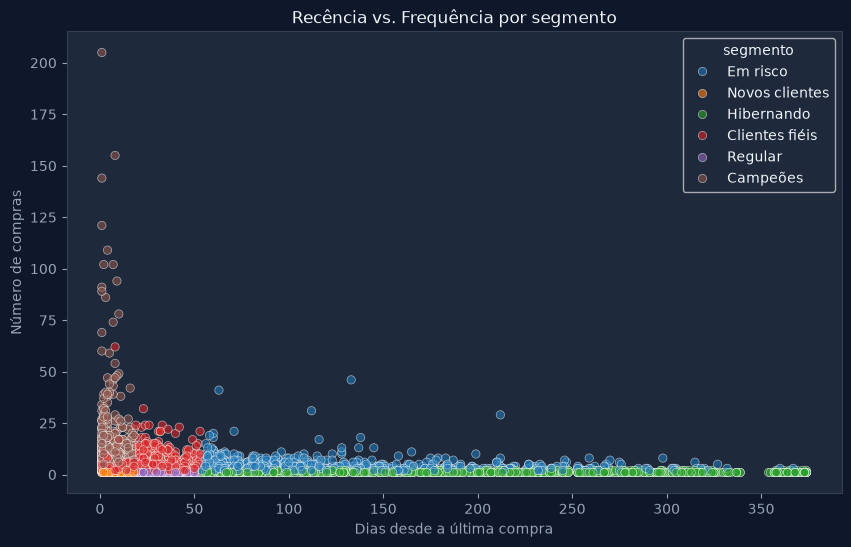

In [27]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='recencia', y='frequencia', hue='segmento', alpha=0.6)
plt.title('Recência vs. Frequência por segmento')
plt.xlabel('Dias desde a última compra')
plt.ylabel('Número de compras')
plt.show()

> O gráfico evidencia a lógica de separação entre os segmentos no espaço recência-frequência. Campeões e Clientes fiéis concentram-se no canto superior esquerdo, com baixa recência (compraram há poucos dias) e frequência elevada. Em risco aparece disperso na faixa de frequência intermediária a alta, mas com recência crescente, confirmando o afastamento progressivo desses clientes. Hibernando forma uma nuvem densa no extremo direito do eixo horizontal, com recência acima de 200 dias e frequência baixa. Novos clientes, apesar de recentes (recência baixa), mostram frequência muito próxima de zero, o que os distingue visualmente dos Campeões na mesma faixa de recência. Alguns pontos com frequência acima de 100 pertencem a Campeões e Clientes fiéis e correspondem aos outliers identificados na distribuição da variável.

---

## 5. Conclusão e Considerações Finais

### 5.1 Síntese do Projeto

O projeto aplicou análise RFM sobre o dataset Online Retail II, cobrindo as etapas de carregamento, inspeção e limpeza dos dados, cálculo das métricas de recência, frequência e valor monetário por cliente, discretização em quartis e classificação em seis segmentos com regras de negócio explícitas. 

A análise manteve todos os países do dataset, dado que o Reino Unido representa 91% das transações válidas, e utilizou `rank(method='first')` em frequência para contornar o problema de bin edges duplicados no `qcut`.

| Métrica | Valor |
|---|---|
| Total de clientes segmentados | 4.312 |
| Número de segmentos identificados | 6 |
| Segmento mais numeroso | Hibernando (~1.450 clientes) |
| Segmento de maior valor monetário médio | Campeões (~£10.000) |

### 5.2 Relevantes

O segmento Em risco apresenta valor monetário médio (~£2.000) equivalente ao de Clientes fiéis, apesar de ter recência baixa e frequência decrescente. Isso indica que esses clientes têm histórico de compra substancial e representam perda financeira concreta caso não retornem. Em uma análise de priorização de campanhas de reativação, esse grupo seria candidato prioritário justamente porque o valor potencial de recuperação é alto e o comportamento anterior comprova capacidade de compra.

### 5.3 Limitações e Considerações

A segmentação por quartis utiliza pontos de corte fixos em quatro grupos, o que pode dividir clientes com comportamentos semelhantes em segmentos diferentes próximos à fronteira dos quartis. As regras de nomeação dos segmentos refletem uma interpretação de negócio possível entre várias igualmente válidas, e o dataset abrange um período e contexto comercial específico, não generalizável a outros tipos de varejo sem reavaliação. Este projeto tem finalidade educacional e de composição de portfólio.

---

## 6. Referências

* DataCamp. [Introduction to Customer Segmentation in Python](https://www.datacamp.com/tutorial/introduction-customer-segmentation-python).
* Dataset: [Online Retail II, UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/502/online+retail+ii).

> Material desenvolvido para estudos e composição de portfólio a partir do tutorial da DataCamp, para o repositório [data-trivium](https://github.com/esscova/data-trivium); com auxílio do Claude Anthropic para revisões e estruturação.
